In [1]:
import json
import pandas as pd
import glob
import seaborn as sns
import re
import os
import matplotlib.pyplot as plt


def flatten_result(d):
    """Flatten nested result dict into a flat dict."""
    flat = {}

    # top-level scalar metadata already embedded in JSON
    for key in ['type', 'epoch', 'run', 'forget_set_type', 'unlearning_item',
                'method', 'epoch_duration', 'total_unlearning_time_up_to_now', 'ToW']:
        if key in d:
            flat[key] = d[key]

    # nested metric dicts -> {split}_{metric} columns (e.g. forget_acc, retain_loss)
    for metric in ['acc', 'loss', 'entropy', 'm_entropy']:
        if metric in d:
            for split, val in d[metric].items():
                flat[f'{split}_{metric}'] = val

    # threshold_MIA -> threshold_MIA.{path} columns
    if 'threshold_MIA' in d:
        mia_flat = pd.json_normalize(d['threshold_MIA'], sep='.')
        for col in mia_flat.columns:
            flat[f'threshold_MIA.{col}'] = mia_flat[col].iloc[0]

    # outputs -> outputs.{path} columns
    if 'outputs' in d:
        out_flat = pd.json_normalize(d['outputs'], sep='.')
        for col in out_flat.columns:
            flat[f'outputs.{col}'] = out_flat[col].iloc[0]

    return flat


def gather_results(results_folder,
                   epochs=None, classes=None, percents=None, runs=None, methods=None,
                   base=True, retrain=True):

    # collect all result json files
    all_files = []
    for root, dirs, files in os.walk(results_folder):
        for fname in files:
            if fname.endswith('.json') and 'config' not in fname:
                all_files.append(os.path.join(root, fname))

    def norm(f):
        return f.replace('\\', '/')

    if not base:
        all_files = [f for f in all_files if '/base/' not in norm(f)]
    if not retrain:
        all_files = [f for f in all_files if '/retrain/' not in norm(f)]

    if classes is not None:
        pattern = rf"class_({'|'.join(map(str, classes))})"
        all_files = [f for f in all_files if re.search(pattern, f)]
    if percents is not None:
        pattern = rf"percent_({'|'.join(map(str, percents))})"
        all_files = [f for f in all_files if re.search(pattern, f)]

    all_rows = []
    for f in all_files:
        with open(f) as fh:
            d = json.load(fh)

        flat = flatten_result(d)

        # class and percent from filename
        m = re.search(r'class_(\d+)', f)
        flat['class'] = int(m.group(1)) if m else -99
        m = re.search(r'percent_(\d+)', f)
        flat['percent'] = int(m.group(1)) if m else -99

        # fill sentinel epoch/run/method for base and retrain (not embedded in those JSONs)
        result_type = flat.get('type', 'unknown')
        if result_type == 'base':
            flat.setdefault('epoch', -99)
            flat.setdefault('run', -99)
            flat.setdefault('method', 'base')
        elif result_type == 'retrain':
            flat.setdefault('epoch', -98)
            flat.setdefault('method', 'retrain')
            m = re.search(r'retrain_run_(\d+)', norm(f))
            flat.setdefault('run', int(m.group(1)) if m else -99)

        all_rows.append(flat)

    if not all_rows:
        raise ValueError("No results - check settings")

    final_df = pd.DataFrame(all_rows)

    # post-load filters (epoch/run/method live in JSON, not path)
    if epochs is not None:
        final_df = final_df[final_df['epoch'].isin(epochs)]
    if runs is not None:
        final_df = final_df[final_df['run'].isin(runs)]
    if methods is not None:
        keep = set(methods) | {'base', 'retrain'}
        final_df = final_df[final_df['method'].isin(keep)]

    if final_df.empty:
        raise ValueError("No results after filtering - check settings")

    return final_df


def results_scatterplot(final_df, x_metric, y_metric,
                        color_by="epoch",
                        base_color="black", retain_color="purple"):

    unique_vals = sorted(final_df[color_by].unique(), key=str)
    colors_list = plt.cm.tab20.colors
    palette_dict = {}
    color_idx = 0
    for val in unique_vals:
        if val == -99 or val == "base":
            palette_dict[val] = base_color
        elif val == -98 or val == "retrain":
            palette_dict[val] = retain_color
        else:
            palette_dict[val] = colors_list[color_idx % len(colors_list)]
            color_idx += 1

    plt.clf()
    sns.set_style("whitegrid")
    sns.scatterplot(
        data=final_df,
        x=x_metric,
        y=y_metric,
        hue=color_by,
        palette=palette_dict,
        alpha=0.7,
        edgecolor=None
    )
    plt.title(f"{x_metric} vs. {y_metric}")
    plt.xlabel(x_metric.capitalize().replace("_", " "))
    plt.ylabel(y_metric.capitalize().replace("_", " "))
    handles, labels = plt.gca().get_legend_handles_labels()
    new_labels = ["base" if l in ("-99", "-99.0") else "retrain" if l in ("-98", "-98.0") else l for l in labels]
    plt.legend(title=color_by.capitalize(), handles=handles, labels=new_labels, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [2]:
results = gather_results("results/seed_4", base=True, retrain=True) 
results

,type,forget_acc,retain_acc,test_acc,forget_loss,retain_loss,test_loss,forget_entropy,retain_entropy,test_entropy,...,epoch_duration,total_unlearning_time_up_to_now,ToW,outputs.retrained_vs_unlearned.forget.absolute_distance,outputs.retrained_vs_unlearned.forget.l2_distance,outputs.retrained_vs_unlearned.forget.JS_divergence,outputs.retrained_vs_unlearned.retain.absolute_distance,outputs.retrained_vs_unlearned.test.absolute_distance,outputs.retrained_vs_unlearned.forget_test_avg.KL_divergence,outputs.unlearned.forget_vs_test.wasserstein_distance
0,base,99.82,99.871111,92.93,0.006728,0.004853,0.339403,0.012881,0.010612,0.055142,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,retrain,0.00,99.888889,84.75,13.844892,0.004126,1.813166,0.191267,0.009616,0.058779,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,retrain,0.00,99.906667,84.74,14.392936,0.004034,1.878863,0.178793,0.009165,0.060031,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,unlearn,97.00,99.902222,92.57,0.085515,0.003923,0.387835,0.071373,0.008894,0.054683,...,17.563473,89155.047894,0.027650,1.956741,1.341907,0.668866,1.776414,0.269589,13.221553,0.304863
4,unlearn,93.66,99.851111,92.18,0.178668,0.005530,0.428275,0.116782,0.009790,0.055801,...,17.137162,175541.433096,0.058650,1.912743,1.307907,0.647266,1.782977,0.259628,13.476119,0.275102
5,unlearn,29.98,89.435556,80.67,5.195192,0.444157,1.274232,0.296202,0.110750,0.116125,...,1.491964,7816.975594,0.601367,1.316715,0.882646,0.415310,1.773513,0.346604,10.578340,3.924262
6,unlearn,99.40,99.868889,92.89,0.018977,0.004530,0.343573,0.025496,0.009738,0.054882,...,1.482522,4832.916498,0.005509,1.989366,1.368400,0.685908,1.776086,0.284901,12.932675,0.324702
7,unlearn,77.82,99.860000,91.02,0.763328,0.005055,0.524816,0.234701,0.009652,0.057458,...,17.964457,90497.254610,0.207774,1.725958,1.166956,0.569794,1.777594,0.234280,12.918231,0.462093
8,unlearn,0.38,99.815556,84.91,16.061757,0.006789,2.180253,0.189238,0.011751,0.053082,...,18.059998,180601.124048,0.993600,0.816742,0.550166,0.243580,1.779980,0.137910,13.928139,13.901918
9,unlearn,19.54,99.777778,85.72,1.814742,0.014479,0.454883,1.769049,0.046820,0.248610,...,10.379065,52027.858734,0.795688,1.658370,0.897129,0.468685,1.768939,0.254765,9.261792,1.560870


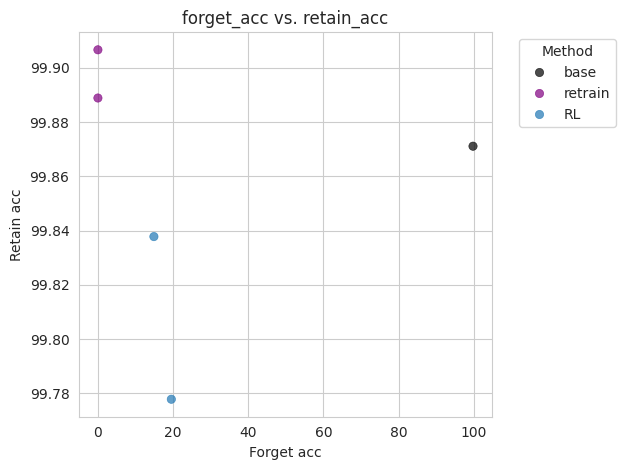

In [17]:
results = gather_results("results/seed_4", base=True, retrain=True, methods = ["RL"]) 
                        #  epochs = [-99, 0, 1, 2, 3, 4, 5, 6])
results_scatterplot(
    results, 
    x_metric = "forget_acc", y_metric = "retain_acc", 
    color_by = "method"
    )